# PCA / t-SNE Explorer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/dim-reducer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/dim-reducer/demo.ipynb)

> "Too many features to see" — project high-dimensional data down to 2D and actually look at its structure.

You can't eyeball 8 dimensions. Dimensionality reduction squeezes them into a 2D picture that
preserves the important structure - so clusters, gradients, and outliers become visible. PCA does it
linearly (and tells you how much you kept); t-SNE does it non-linearly (great for separating clusters).

**What this notebook covers**
1. PCA to 2D + explained variance
2. The scree plot: how many dimensions you really need
3. t-SNE for non-linear cluster separation
4. PCA vs t-SNE side by side
5. When to trust which


## Step 1 - PCA: 8D → 2D, and how much survived

Three gaussian blobs live in 8 dimensions. PCA finds the 2 directions of greatest variance and
projects onto them - reporting exactly what fraction of the information those 2 axes retain.

In [1]:
from dimreduce import pca_project, tsne_project, scree, sample_dataframe

df = sample_dataframe()
proj = pca_project(df, "label")
print(f"Features: {df.select_dtypes('number').shape[1]}D  ->  2D")
print(f"Explained variance: PC1={proj.explained_variance[0]:.1%}, PC2={proj.explained_variance[1]:.1%}")
print(f"Kept in 2D: {sum(proj.explained_variance):.1%}")


Features: 8D  ->  2D
Explained variance: PC1=63.6%, PC2=23.4%
Kept in 2D: 86.9%


## Step 2 - The scree plot decision

How many components do you actually need? The scree curve shows variance per component; the elbow is
where extra dimensions stop paying off. Here 2-3 components carry almost everything.

In [2]:
sc = scree(df, "label")
cum = 0
for i, r in enumerate(sc, 1):
    cum += r
    bar = "#" * int(r * 50)
    print(f"PC{i}: {r:5.1%} {bar:<26} cumulative {cum:5.1%}")


PC1: 63.6% ############################### cumulative 63.6%
PC2: 23.4% ###########                cumulative 86.9%
PC3:  4.3% ##                         cumulative 91.2%
PC4:  3.1% #                          cumulative 94.3%
PC5:  2.0% #                          cumulative 96.3%
PC6:  1.7%                            cumulative 98.0%
PC7:  1.2%                            cumulative 99.2%
PC8:  0.8%                            cumulative 100.0%


## Step 3 - Visualize both projections

PCA preserves global geometry (distances between clusters mean something). t-SNE optimizes local
neighborhoods (tight, well-separated blobs, but cluster *sizes/distances* aren't meaningful). Both
should recover the three groups.

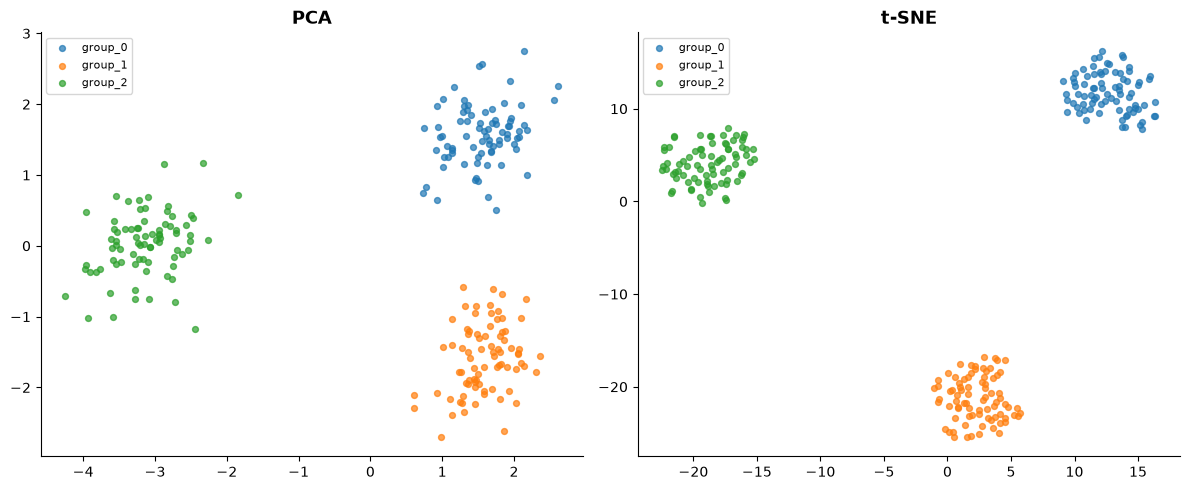

In [3]:
import matplotlib.pyplot as plt

pca = pca_project(df, "label")
tsne = tsne_project(df, "label")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, proj in zip(axes, [pca, tsne]):
    uniq = list(dict.fromkeys(proj.labels))
    cmap = plt.get_cmap("tab10")
    for i, lab in enumerate(uniq):
        m = proj.labels == lab
        ax.scatter(proj.coords[m, 0], proj.coords[m, 1], s=18, alpha=0.7, color=cmap(i), label=str(lab))
    ax.set_title(proj.method, fontsize=13, weight="bold")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("projections.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Method | Preserves | Read cluster distances? | Explained variance? |
|--------|-----------|-------------------------|---------------------|
| PCA | global variance | yes | yes |
| t-SNE | local neighborhoods | **no** | no |

Reach for **PCA** first: it's fast, deterministic, and tells you how much you kept. Use **t-SNE**
(or UMAP) when clusters overlap in the linear projection and you just need to *see* separation - but
never read distances between t-SNE blobs as meaningful.

**Extend it:** add UMAP, let PCA feed t-SNE (denoise then separate), and color by a continuous
variable to spot gradients.

In [4]:
# --- Try your own data ---
# import pandas as pd
# my_df = pd.read_csv("your_data.csv")
# p = pca_project(my_df, label_col="your_label_column")
# print("kept in 2D:", sum(p.explained_variance))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 113,
Month 12: Data Science Cookbook.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`